# Transformer for silver: data prep, model, training, and evaluation

Applies everything learned from gold's transformer work directly, rather than repeating the same debugging journey:
- Split boundary pinned to GARCH's exact test period from the start (no validation/test leakage)
- Learning rate `1e-4` from the start (the fix that came out of gold's collapsed-training diagnosis)
- Straight to a clean, honest comparison against GARCH, naive, and linear baselines

Silver's GARCH backtest (notebook 08) used the same test period as gold: **2023-04-12 to 2026-08-05**.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
WINDOW_SIZE = 30
GARCH_TEST_START = "2023-04-12"
GARCH_TEST_END = "2026-08-05"

## Data prep: windows, date-aligned split, normalization

In [2]:
silver = pd.read_csv("../data/silver_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
returns = silver["Close"].pct_change().dropna() * 100


def create_windows(returns, window_size):
    values = returns.values
    X, y, dates = [], [], []
    for start in range(len(values) - window_size):
        end = start + window_size
        X.append(values[start:end])
        y.append(abs(values[end]))
        dates.append(returns.index[end])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DatetimeIndex(dates)


X, y, dates = create_windows(returns, WINDOW_SIZE)

test_mask = (dates >= GARCH_TEST_START) & (dates <= GARCH_TEST_END)
X_pretest, y_pretest = X[~test_mask], y[~test_mask]
X_test, y_test, dates_test = X[test_mask], y[test_mask], dates[test_mask]

train_end = int(len(X_pretest) * 0.85)
X_train, y_train = X_pretest[:train_end], y_pretest[:train_end]
X_val, y_val = X_pretest[train_end:], y_pretest[train_end:]

train_mean = X_train.mean()
train_std = X_train.std()
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std


def to_dataset(X, y):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32)
    return TensorDataset(X_t, y_t)


train_loader = DataLoader(to_dataset(X_train_norm, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(to_dataset(X_val_norm, y_val), batch_size=64, shuffle=False)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(f"Test date range: {dates_test[0].date()} to {dates_test[-1].date()}")

Train: 2810  Val: 496  Test: 834
Test date range: 2023-04-12 to 2026-08-05


## Model architecture (same as gold's)

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


class VolatilityTransformer(nn.Module):
    def __init__(self, d_model=32, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=64, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.encoder(x)
        last_day = x[:, -1, :]
        out = self.output_head(last_day)
        return nn.functional.softplus(out).squeeze(-1)


model = VolatilityTransformer()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 17,185


## Train (lr=1e-4, 150 epochs - the settings that fixed gold's collapsed training)

In [4]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NUM_EPOCHS = 150
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(batch_y)
    train_loss = running_loss / len(X_train)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = loss_fn(predictions, batch_y)
            running_val_loss += loss.item() * len(batch_y)
    val_loss = running_val_loss / len(X_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1:3d}/{NUM_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

torch.save(
    {"state_dict": model.state_dict(), "train_mean": train_mean, "train_std": train_std},
    "../models/silver_transformer.pt",
)
print("Saved to ../models/silver_transformer.pt")

Epoch  25/150  train_loss=1.8961  val_loss=1.5507


Epoch  50/150  train_loss=1.8788  val_loss=1.5504


Epoch  75/150  train_loss=1.8455  val_loss=1.5410


Epoch 100/150  train_loss=1.8421  val_loss=1.5320


Epoch 125/150  train_loss=1.8048  val_loss=1.5342


Epoch 150/150  train_loss=1.7978  val_loss=1.5340

Best validation loss: 1.4953
Saved to ../models/silver_transformer.pt


## Diagnostic: did it collapse to predicting the mean, like gold's first attempt?

In [5]:
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32).unsqueeze(-1)
model.eval()
with torch.no_grad():
    predictions_transformer = model(X_test_tensor).numpy()

print(f"Actual  -> mean: {y_test.mean():.4f}  std: {y_test.std():.4f}")
print(f"Predicted -> mean: {predictions_transformer.mean():.4f}  std: {predictions_transformer.std():.4f}")
print(f"Prediction std as % of actual std: {predictions_transformer.std() / y_test.std() * 100:.1f}%")

rmse_transformer = np.sqrt(np.mean((predictions_transformer - y_test) ** 2))
print(f"\nTransformer RMSE (test period): {rmse_transformer:.4f}")

Actual  -> mean: 1.7728  std: 2.0688
Predicted -> mean: 1.4473  std: 0.2492
Prediction std as % of actual std: 12.0%

Transformer RMSE (test period): 2.0116


## Baselines: naive, linear regression, and GARCH's actual forecast

In [6]:
from arch import arch_model

# Naive
naive_prediction = np.full_like(y_test, y_train.mean())
rmse_naive = np.sqrt(np.mean((naive_prediction - y_test) ** 2))

# Linear regression, 30 raw values
X_train_design = np.hstack([np.ones((len(X_train), 1)), X_train]).astype(np.float64)
X_test_design = np.hstack([np.ones((len(X_test), 1)), X_test]).astype(np.float64)
coeffs_full, *_ = np.linalg.lstsq(X_train_design, y_train.astype(np.float64), rcond=None)
predictions_full = X_test_design @ coeffs_full
rmse_full = np.sqrt(np.mean((predictions_full - y_test) ** 2))

# Linear regression, 1 feature (recent realized vol)
recent_vol_train = np.abs(X_train).mean(axis=1)
recent_vol_test = np.abs(X_test).mean(axis=1)
X_train_simple = np.column_stack([np.ones(len(X_train)), recent_vol_train]).astype(np.float64)
X_test_simple = np.column_stack([np.ones(len(X_test)), recent_vol_test]).astype(np.float64)
coeffs_simple, *_ = np.linalg.lstsq(X_train_simple, y_train.astype(np.float64), rcond=None)
predictions_simple = X_test_simple @ coeffs_simple
rmse_simple = np.sqrt(np.mean((predictions_simple - y_test) ** 2))

# GARCH (recomputed here for the plot; RMSE=2.0044 already known from notebook 08)
garch_split_idx = int(len(returns) * 0.8)
garch_split_date = returns.index[garch_split_idx]
garch_model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
garch_result = garch_model.fit(last_obs=garch_split_date, disp="off")
garch_forecasts = garch_result.forecast(start=garch_split_date, horizon=1, reindex=False)
garch_volatility = np.sqrt(garch_forecasts.variance["h.1"])
GARCH_RMSE = 2.0044  # from notebook 08

print(f"Naive RMSE:                  {rmse_naive:.4f}")
print(f"Linear (30 raw values) RMSE: {rmse_full:.4f}")
print(f"Linear (1 feature) RMSE:     {rmse_simple:.4f}")
print(f"GARCH(1,1) RMSE:             {GARCH_RMSE:.4f}")
print(f"Transformer RMSE:            {rmse_transformer:.4f}")

Naive RMSE:                  2.1168
Linear (30 raw values) RMSE: 2.1063
Linear (1 feature) RMSE:     1.8918
GARCH(1,1) RMSE:             2.0044
Transformer RMSE:            2.0116


## Final scoreboard and plots

                            Model      RMSE  Improvement over naive
0  Linear (1 feature: recent vol)  1.891763               10.631616
1                      GARCH(1,1)  2.004400                5.310566
2                     Transformer  2.011552                4.972718
3          Linear (30 raw values)  2.106268                0.498246
4              Naive (train mean)  2.116815                0.000000


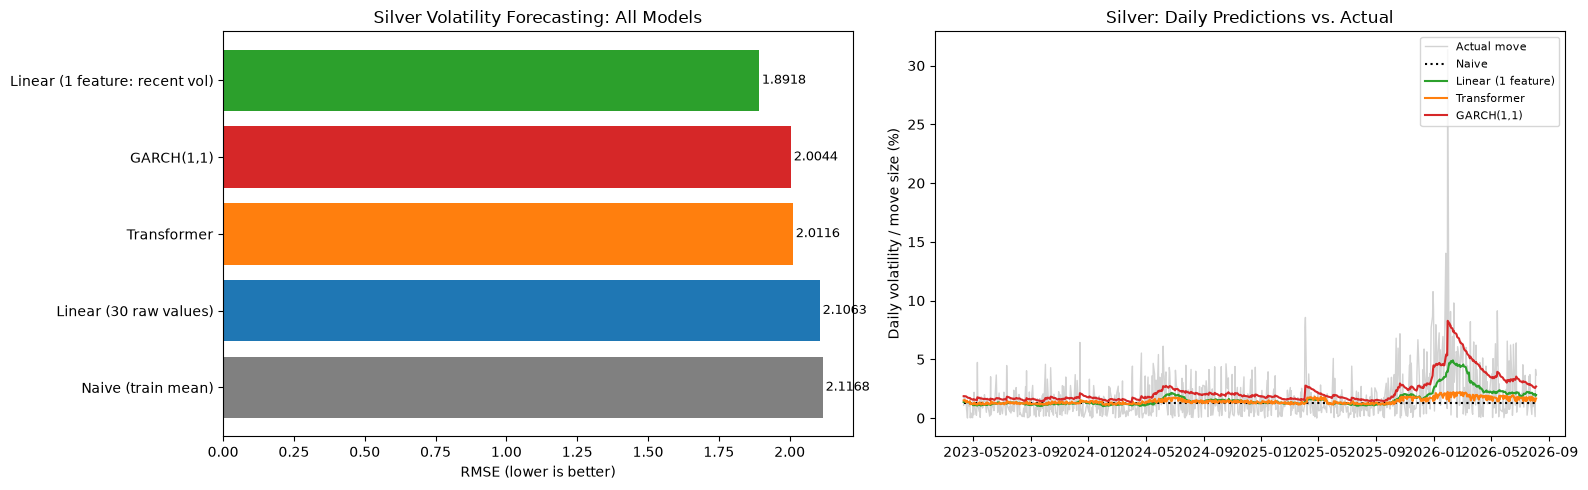

In [7]:
results = pd.DataFrame({
    "Model": ["Naive (train mean)", "Linear (30 raw values)", "Linear (1 feature: recent vol)", "Transformer", "GARCH(1,1)"],
    "RMSE": [rmse_naive, rmse_full, rmse_simple, rmse_transformer, GARCH_RMSE],
})
results["Improvement over naive"] = (1 - results["RMSE"] / rmse_naive) * 100
results_sorted = results.sort_values("RMSE").reset_index(drop=True)
print(results_sorted)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {"Naive (train mean)": "gray", "Linear (30 raw values)": "tab:blue",
          "Linear (1 feature: recent vol)": "tab:green", "Transformer": "tab:orange", "GARCH(1,1)": "tab:red"}
bar_colors = [colors[m] for m in results_sorted["Model"]]
bars = axes[0].barh(results_sorted["Model"], results_sorted["RMSE"], color=bar_colors)
axes[0].set_xlabel("RMSE (lower is better)")
axes[0].set_title("Silver Volatility Forecasting: All Models")
axes[0].invert_yaxis()
for bar, rmse in zip(bars, results_sorted["RMSE"]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{rmse:.4f}", va="center", fontsize=9)

axes[1].plot(dates_test, y_test, color="lightgray", label="Actual move", linewidth=1)
axes[1].plot(dates_test, naive_prediction, color="black", linestyle=":", label="Naive", linewidth=1.5)
axes[1].plot(dates_test, predictions_simple, color="tab:green", label="Linear (1 feature)", linewidth=1.5)
axes[1].plot(dates_test, predictions_transformer, color="tab:orange", label="Transformer", linewidth=1.5)
axes[1].plot(garch_volatility.index, garch_volatility.values, color="tab:red", label="GARCH(1,1)", linewidth=1.5)
axes[1].set_title("Silver: Daily Predictions vs. Actual")
axes[1].set_ylabel("Daily volatility / move size (%)")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()